# <span style="color:darkblue"> Lecture 3c: Transform </span>

<font size = "5">

This is a complement to Lecture 3b


# <span style="color:darkblue"> I. Import Libraries and Data </span>


<font size = "5">
Key libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
results = pd.read_csv("data_raw/results.csv")

# <span style="color:darkblue"> II. Transform + Groupby </span>



<font size = "5">

Adding columns with grouped aggregate statistics

<img src="figures/transform_stats.png" alt="drawing" width="300"/>


In [3]:
display(results)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25835,25841,1096,854,210,47,12,16,16,16,0.0,57,\N,\N,39,12,1:29.833,211.632,11
25836,25842,1096,825,210,20,16,17,17,17,0.0,57,\N,\N,40,20,1:31.158,208.556,11
25837,25843,1096,1,131,44,5,18,18,18,0.0,55,\N,\N,42,11,1:29.788,211.738,9
25838,25844,1096,849,3,6,20,19,19,19,0.0,55,\N,\N,45,14,1:30.309,210.517,130


In [4]:
display(results.groupby("driverId")["points"].mean())
print(type(results.groupby("driverId")["points"].mean()))

driverId
1      14.182258
2       1.407609
3       7.740291
4       5.756983
5       0.937500
         ...    
852     1.000000
853     0.000000
854     0.272727
855     0.272727
856     2.000000
Name: points, Length: 855, dtype: float64

<class 'pandas.core.series.Series'>


In [5]:
display(results.groupby("driverId")["points"].transform("mean"))

0        14.182258
1         1.407609
2         7.740291
3         5.756983
4         0.937500
           ...    
25835     0.272727
25836     1.260563
25837    14.182258
25838     0.147541
25839     5.756983
Name: points, Length: 25840, dtype: float64

In [6]:
display(results.groupby("driverId")["points"].apply("mean"))

driverId
1      14.182258
2       1.407609
3       7.740291
4       5.756983
5       0.937500
         ...    
852     1.000000
853     0.000000
854     0.272727
855     0.272727
856     2.000000
Name: points, Length: 855, dtype: float64

In [7]:
help(results.groupby("driverId")["points"].transform)

Help on method transform in module pandas.core.groupby.generic:

transform(func, *args, engine=None, engine_kwargs=None, **kwargs) method of pandas.core.groupby.generic.SeriesGroupBy instance
    Call function producing a same-indexed Series on each group.

    Returns a Series having the same indexes as the original object
    filled with the transformed values.

    Parameters
    ----------
    f : function, str
        Function to apply to each group. See the Notes section below for requirements.

        Accepted inputs are:

        - String
        - Python function
        - Numba JIT function with ``engine='numba'`` specified.

        Only passing a single function is supported with this engine.
        If the ``'numba'`` engine is chosen, the function must be
        a user defined function with ``values`` and ``index`` as the
        first and second arguments respectively in the function signature.
        Each group's index will be passed to the user defined function
    

In [8]:
# We've use "transform" to compute a column with aggregate statistics
# If we add the pipe "groupby" the aggregate statistics are computed by group
# with group level averages.
# We can use any aggregate function, including "mean", "std", "max","min", etc.

results["mean_points_driver"] = results.groupby("driverId")["points"].transform("mean")
results["std_points_driver"]  = results.groupby("driverId")["points"].transform("std")


<font size = "5">

Computing the rank


In [9]:
help(results["points"].rank)

Help on method rank in module pandas.core.generic:

rank(
    axis: 'Axis' = 0,
    method: "Literal['average', 'min', 'max', 'first', 'dense']" = 'average',
    numeric_only: 'bool_t' = False,
    na_option: "Literal['keep', 'top', 'bottom']" = 'keep',
    ascending: 'bool_t' = True,
    pct: 'bool_t' = False
) -> 'Self' method of pandas.core.series.Series instance
    Compute numerical data ranks (1 through n) along axis.

    By default, equal values are assigned a rank that is the average of the
    ranks of those values.

    Parameters
    ----------
    axis : {0 or 'index', 1 or 'columns'}, default 0
        Index to direct ranking.
        For `Series` this parameter is unused and defaults to 0.
    method : {'average', 'min', 'max', 'first', 'dense'}, default 'average'
        How to rank the group of records that have the same value (i.e. ties):

        * average: average rank of the group
        * min: lowest rank in the group
        * max: highest rank in the group
    

In [14]:
# The rank function calculates the relative position
# The option 'method = "dense"' options gives multiple individuals
# the same rank if there is a tie
# The option 'ascending = False' indicates the the person with the lowest
# score is "1", the second lowest is "2", etc.

results["rank_points"] = results["points"].rank(method = "dense",
                                                ascending = False)

# results["rank_points"] = results["points"].rank(method = "min",
#                                                 ascending = False)

In [11]:
results.sort_values("points", ascending=False)[["points", "rank_points"]]

,points,rank_points
22514,50.0,1.0
22515,36.0,2.0
22516,30.0,3.0
25440,26.0,4.0
24780,26.0,4.0
...,...,...
10071,0.0,7711.0
10070,0.0,7711.0
10069,0.0,7711.0
10068,0.0,7711.0


Text(0.5, 0, 'Relative Ranking')

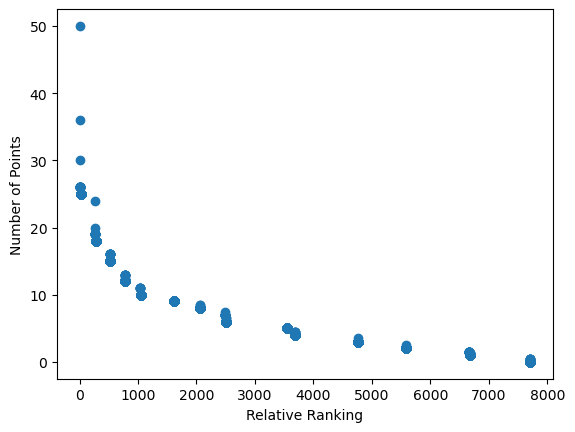

In [12]:
# The graph shows that the winner gets 50 points
plt.scatter(x = results["rank_points"],y = results["points"])
plt.ylabel("Number of Points")
plt.xlabel("Relative Ranking")

Text(0.5, 0, 'Relative Ranking')

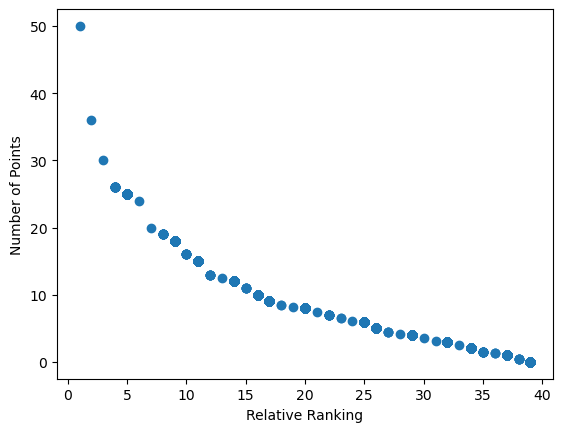

In [15]:
# The graph shows that the winner gets 50 points
plt.scatter(x = results["rank_points"],y = results["points"])
plt.ylabel("Number of Points")
plt.xlabel("Relative Ranking")

<font size = "5">

Computing the rank by group

In [16]:
# The subfunction "transform" allows us to pass-along some of the options

results["rank_points_withinteam"] = (results.groupby("constructorId")["points"]
                                            .transform("rank",
                                                       method = "dense",
                                                       ascending = True))

In [17]:
results

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,mean_points_driver,std_points_driver,rank_points,rank_points_withinteam
0,1,18,1,1,22,1,1,1,1,10.0,...,5690616,39,2,1:27.452,218.300,1,14.182258,9.224098,16.0,13.0
1,2,18,2,2,3,5,2,2,2,8.0,...,5696094,41,3,1:27.739,217.586,1,1.407609,2.372923,20.0,8.0
2,3,18,3,3,7,7,3,3,3,6.0,...,5698779,41,5,1:28.090,216.719,1,7.740291,8.672456,25.0,9.0
3,4,18,4,4,5,11,4,4,4,5.0,...,5707797,58,7,1:28.603,215.464,1,5.756983,6.330721,26.0,6.0
4,5,18,5,1,23,3,5,5,5,4.0,...,5708630,43,1,1:27.418,218.385,1,0.937500,1.969503,29.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25835,25841,1096,854,210,47,12,16,16,16,0.0,...,\N,39,12,1:29.833,211.632,11,0.272727,1.335798,39.0,1.0
25836,25842,1096,825,210,20,16,17,17,17,0.0,...,\N,40,20,1:31.158,208.556,11,1.260563,2.771894,39.0,1.0
25837,25843,1096,1,131,44,5,18,18,18,0.0,...,\N,42,11,1:29.788,211.738,9,14.182258,9.224098,39.0,1.0
25838,25844,1096,849,3,6,20,19,19,19,0.0,...,\N,45,14,1:30.309,210.517,130,0.147541,0.813143,39.0,1.0
